In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image
from tqdm.notebook import tqdm 
import pickle 



In [2]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50, VGG16, EfficientNetB0
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

# Metrics
from sklearn.metrics.pairwise import cosine_similarity


2025-04-26 13:43:29.719348: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None) # Полезно для просмотра длинных имен или путей
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 6) # Размер графиков по умолчанию

print("TensorFlow Version:", tf.__version__)
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print("GPU доступен:", gpu_devices)
    tf.config.experimental.set_memory_growth(gpu_devices[0], True) # Попытка избежать занятия всей памяти GPU сразу
else:
    print("GPU не найден, будет использоваться CPU.")


TensorFlow Version: 2.16.2
GPU не найден, будет использоваться CPU.


In [ ]:
# ============================================
# Конфигурация Путей и Параметров
# ============================================
metadata_path = '/Users/andreyserba/Desktop/reksis/rek_project2/archive-2/styles.csv' # /Users/andreyserba/Desktop/reksis/rek_project2/archive-2/styles.csv
image_folder = '/Users/andreyserba/Desktop/reksis/rek_project2/archive-2/images'

TARGET_IMG_SIZE = (224, 224) # Стандартный размер для многих моделей

TOP_N_RECOMMENDATIONS = 6 # Сколько рекомендаций показывать
N_QUALITATIVE_SAMPLES = 3 # Сколько примеров товаров использовать для визуальной оценки
N_QUANTITATIVE_SAMPLES = 100 # Сколько примеров использовать для прокси-метрики (уменьши, если долго)

FEATURES_PATH = 'best_model_features.npy'
IDS_PATH = 'product_ids.npy'
METADATA_PATH_PROCESSED = 'processed_metadata.pkl'


In [ ]:
# ============================================
# ШАГ 1: Загрузка датасета (Метаданные)
# ============================================
print("\n--- Шаг 1: Загрузка метаданных ---")
try:
    df = pd.read_csv(metadata_path, on_bad_lines='skip')
    print(f"Метаданные успешно загружены. Форма: {df.shape}")
    if not pd.api.types.is_numeric_dtype(df['id']):
        print("Предупреждение: Колонка 'id' имеет нечисловой тип. Убедитесь, что имена файлов изображений соответствуют.")
except FileNotFoundError:
    print(f"ОШИБКА: Файл метаданных не найден по пути {metadata_path}")
except Exception as e:
    print(f"ОШИБКА при чтении CSV: {e}")



--- Шаг 1: Загрузка метаданных ---
Метаданные успешно загружены. Форма: (44424, 10)



--- Шаг 2: EDA (Exploratory Data Analysis) ---

[EDA] Первые 5 строк:
      id gender masterCategory subCategory  articleType baseColour  season  \
0  15970    Men        Apparel     Topwear       Shirts  Navy Blue    Fall   
1  39386    Men        Apparel  Bottomwear        Jeans       Blue  Summer   
2  59263  Women    Accessories     Watches      Watches     Silver  Winter   
3  21379    Men        Apparel  Bottomwear  Track Pants      Black    Fall   
4  53759    Men        Apparel     Topwear      Tshirts       Grey  Summer   

     year   usage                             productDisplayName  
0  2011.0  Casual               Turtle Check Men Navy Blue Shirt  
1  2012.0  Casual             Peter England Men Party Blue Jeans  
2  2016.0  Casual                       Titan Women Silver Watch  
3  2011.0  Casual  Manchester United Men Solid Black Track Pants  
4  2012.0  Casual                          Puma Men Grey T-shirt  

[EDA] Информация о DataFrame:
<class 'pandas.core.frame.D

/var/folders/l6/hgcfppld1r9b94p4h4m34fgh0000gn/T/ipykernel_30329/1677831548.py:37: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna('Unknown', inplace=True)


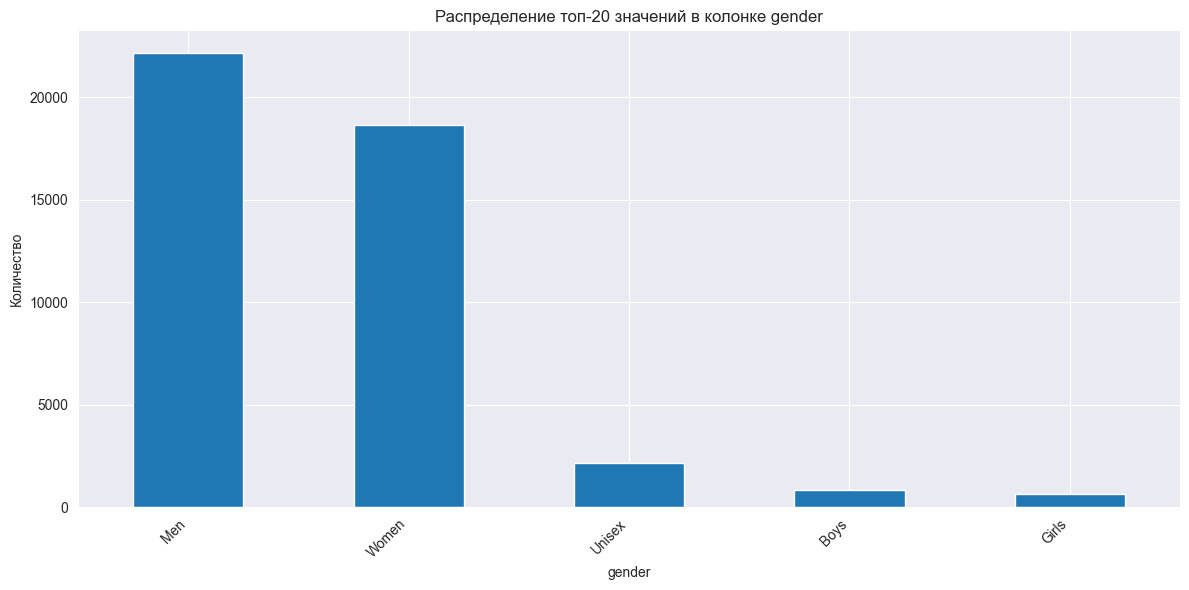

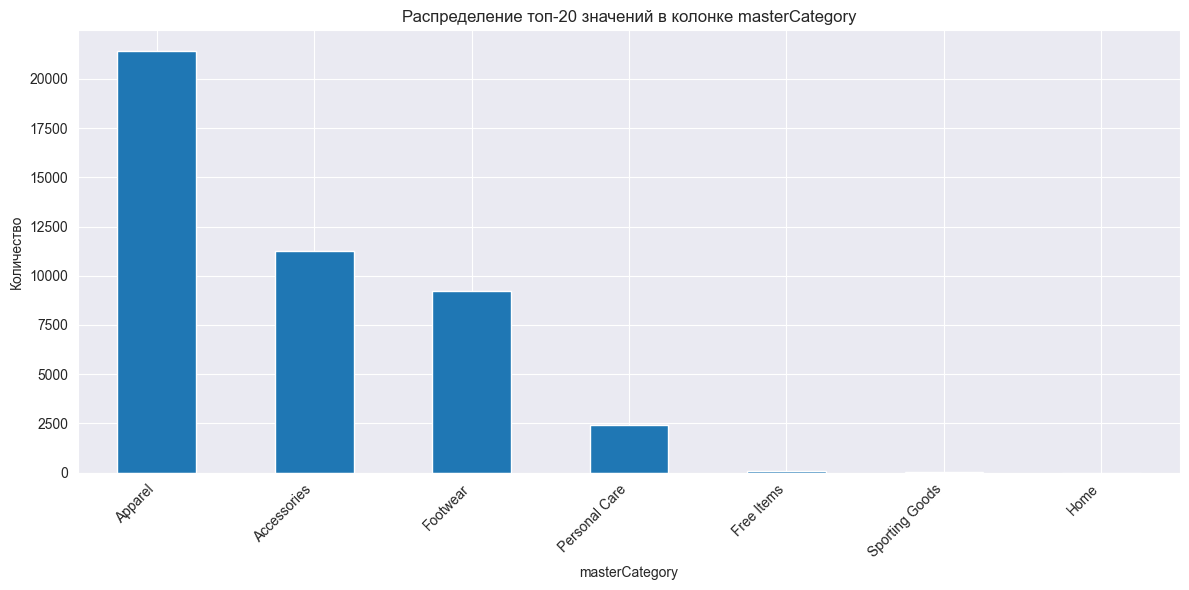

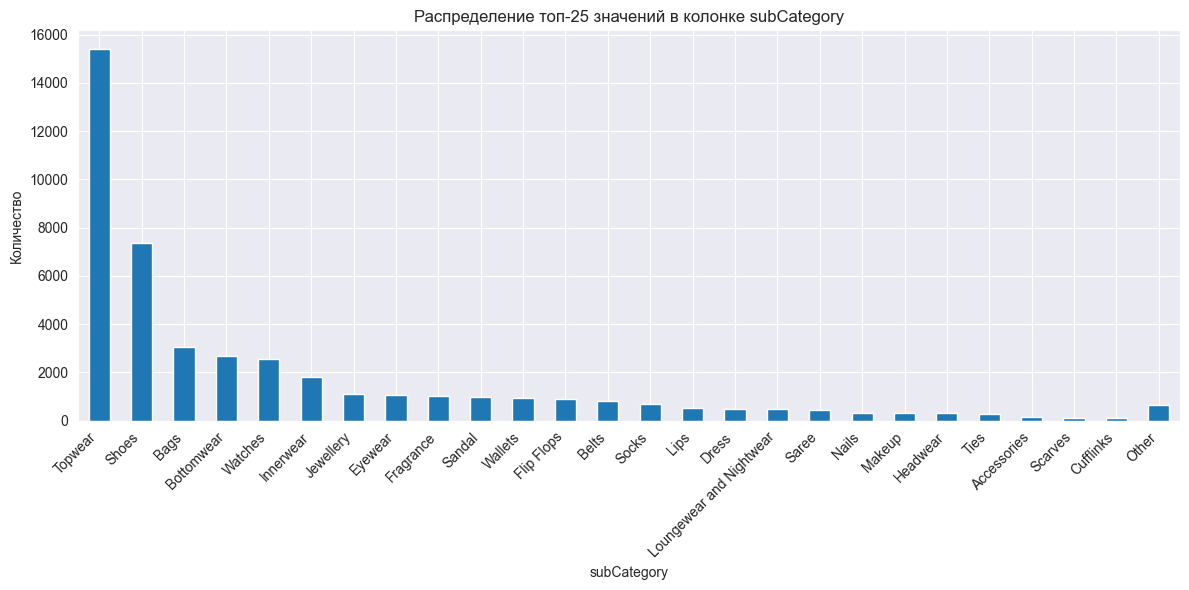

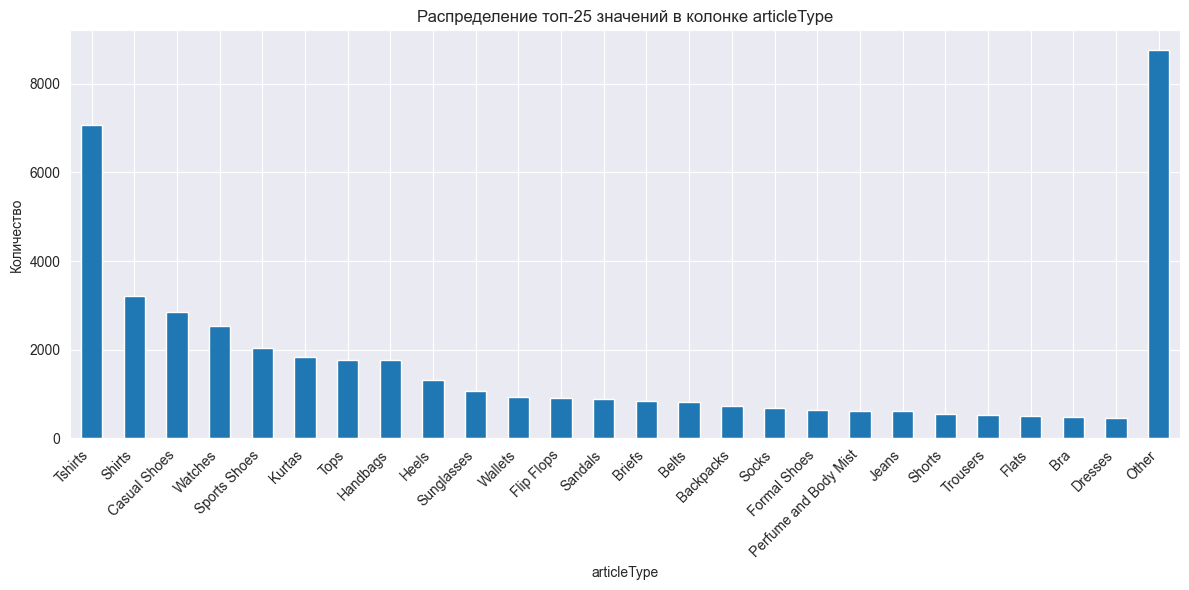

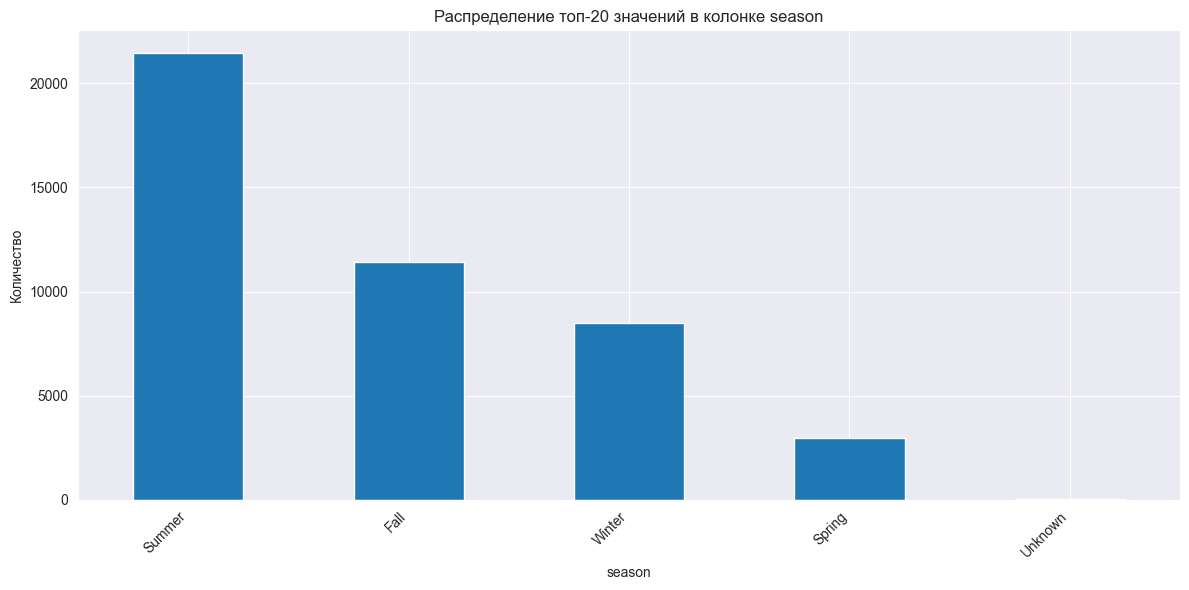

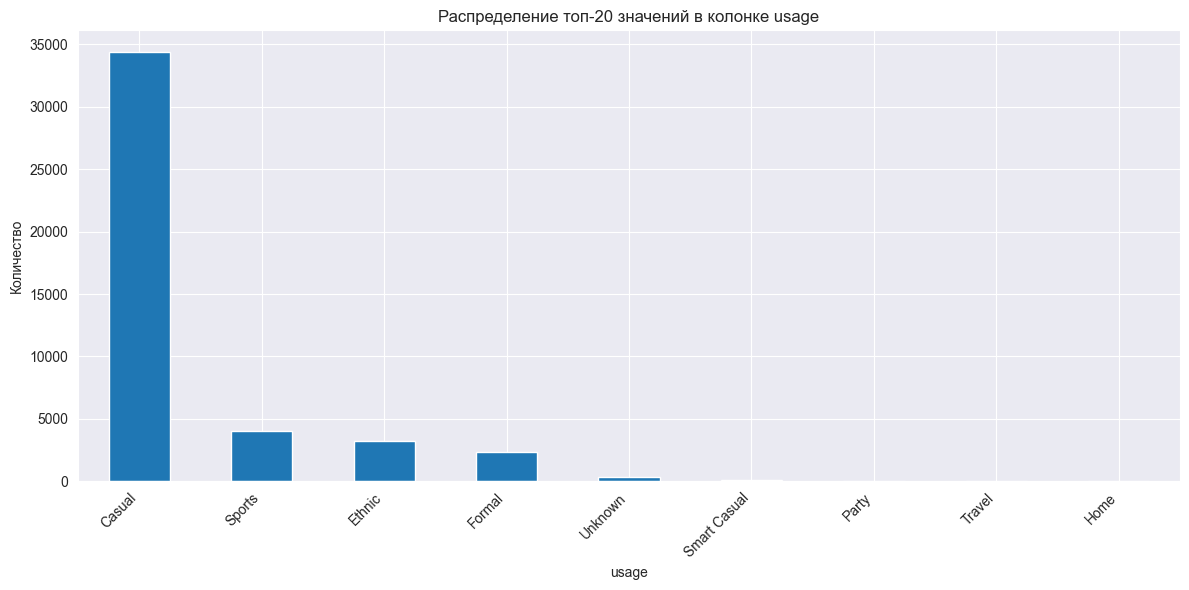


[EDA] Проверка наличия файлов изображений...
[EDA] Проверка существования каждого файла изображения (может занять время)...
[EDA] Найдено 5 записей без соответствующего файла изображения.
[EDA] DataFrame отфильтрован. Осталось 44419 товаров с изображениями.
[EDA] ВНИМАНИЕ: Применяем сэмплирование! Обрабатываем только 450 случайных товаров для ускорения.

[EDA] Примеры товаров с изображениями:


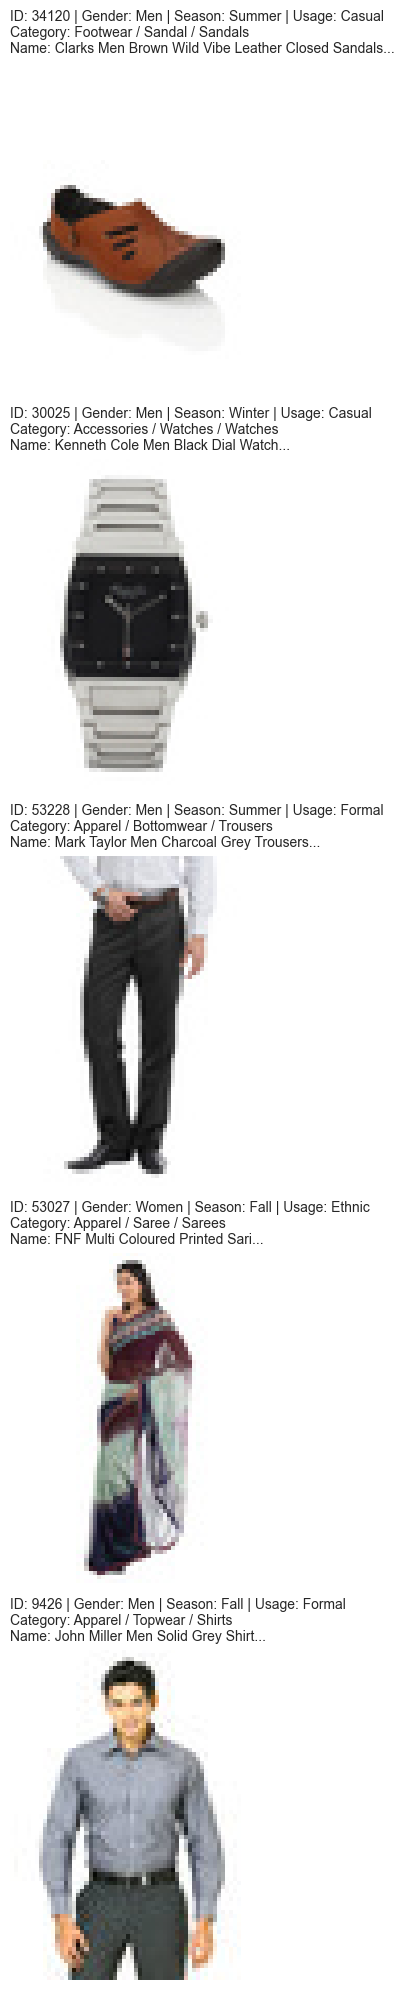

In [ ]:
# ============================================
# ШАГ 2: EDA (Exploratory Data Analysis)
# ============================================
print("\n--- Шаг 2: EDA (Exploratory Data Analysis) ---")

if 'df' in locals(): # Продолжаем, только если df был успешно загружен
    print("\n[EDA] Первые 5 строк:")
    print(df.head())

    print("\n[EDA] Информация о DataFrame:")
    df.info()

    print("\n[EDA] Статистика для числовых колонок:")
    print(df.describe())

    print("\n[EDA] Статистика для категориальных колонок:")
    # Могут быть ошибки, если числовые колонки распознались как object
    try:
        print(df.describe(include='object'))
    except Exception as e:
        print(f"Не удалось получить статистику для object: {e}")


    print("\n[EDA] Проверка на пропущенные значения:")
    missing_values = df.isnull().sum()
    print(missing_values[missing_values > 0]) # Показываем только колонки с пропусками

    for col in ['season', 'usage']: # Добавь другие колонки при необходимости
        if col in df.columns and df[col].isnull().any():
            print(f"\n[EDA] Заполнение пропусков в '{col}' значением 'Unknown'.")
            df[col].fillna('Unknown', inplace=True)

    print("\n[EDA] Анализ распределений:")
    def plot_value_counts(dataframe, column_name, top_n=20):
        plt.figure(figsize=(12, 6))
        try:
             counts = dataframe[column_name].value_counts()
             if len(counts) > top_n:
                 top_counts = counts.head(top_n)
                 other_count = counts.iloc[top_n:].sum()
                 if other_count > 0:
                      top_counts['Other'] = other_count
                 counts_to_plot = top_counts
             else:
                 counts_to_plot = counts

             counts_to_plot.plot(kind='bar')
             plt.title(f'Распределение топ-{top_n} значений в колонке {column_name}')
             plt.xlabel(column_name)
             plt.ylabel('Количество')
             plt.xticks(rotation=45, ha='right')
             plt.tight_layout()
             plt.show()
        except KeyError:
             print(f"Колонка '{column_name}' не найдена в DataFrame.")
        except Exception as e:
             print(f"Ошибка при построении графика для '{column_name}': {e}")


    plot_value_counts(df, 'gender')
    plot_value_counts(df, 'masterCategory')
    plot_value_counts(df, 'subCategory', top_n=25)
    plot_value_counts(df, 'articleType', top_n=25)
    plot_value_counts(df, 'season')
    plot_value_counts(df, 'usage')

    print("\n[EDA] Проверка наличия файлов изображений...")
    if not os.path.isdir(image_folder):
        print(f"ОШИБКА: Папка с изображениями не найдена: {image_folder}")
        df_processed = pd.DataFrame() # Создаем пустой DataFrame, чтобы последующий код не упал
    else:
        def get_image_path(product_id, folder=image_folder):
            # ID в датасете числовой, а имена файлов - строки 'id.jpg'
            filename = f"{int(product_id)}.jpg" if pd.api.types.is_numeric_dtype(df['id']) else f"{product_id}.jpg"
            return os.path.join(folder, filename)

        # Создаем полный путь
        df['image_path'] = df['id'].apply(get_image_path)

        print("[EDA] Проверка существования каждого файла изображения (может занять время)...")
        df['image_exists'] = df['image_path'].apply(os.path.exists)

        missing_images_count = df['image_exists'].value_counts().get(False, 0)
        print(f"[EDA] Найдено {missing_images_count} записей без соответствующего файла изображения.")

        df_processed = df[df['image_exists']].copy()
        df_processed.drop('image_exists', axis=1, inplace=True)
        df_processed.reset_index(drop=True, inplace=True)

        print(f"[EDA] DataFrame отфильтрован. Осталось {len(df_processed)} товаров с изображениями.")

        _SAMPLE_SIZE = 450
        if len(df_processed) > _SAMPLE_SIZE:
            print(f"[EDA] ВНИМАНИЕ: Применяем сэмплирование! Обрабатываем только {_SAMPLE_SIZE} случайных товаров для ускорения.")
            df_processed = df_processed.sample(_SAMPLE_SIZE, random_state=42).reset_index(drop=True)
        else:
            print(f"[EDA] Размер датасета ({len(df_processed)}) меньше или равен _SAMPLE_SIZE, сэмплирование не применяется.")

        print("\n[EDA] Примеры товаров с изображениями:")
        def display_samples(dataframe, n_samples=5):
            samples = dataframe.sample(min(n_samples, len(dataframe))) # Берем min, если товаров меньше чем n_samples
            plt.figure(figsize=(15, n_samples * 4)) # Увеличил высоту для лучшей читаемости
            for i, (index, row) in enumerate(samples.iterrows()):
                plt.subplot(n_samples, 1, i + 1)
                try:
                    img = Image.open(row['image_path'])
                    plt.imshow(img)
                    plt.axis('off')
                    title = (f"ID: {row['id']} | Gender: {row.get('gender', 'N/A')} | Season: {row.get('season', 'N/A')} | Usage: {row.get('usage', 'N/A')}\n"
                             f"Category: {row.get('masterCategory', 'N/A')} / {row.get('subCategory', 'N/A')} / {row.get('articleType', 'N/A')}\n"
                             f"Name: {row.get('productDisplayName', 'N/A')[:80]}...") # Ограничим длину имени
                    plt.title(title, loc='left', fontsize=10)
                except FileNotFoundError:
                    plt.title(f"Image not found for ID: {row['id']} at path: {row['image_path']}", loc='left', color='red')
                except Exception as e:
                     plt.title(f"Error loading image for ID: {row['id']}: {e}", loc='left', color='red')
            plt.tight_layout()
            plt.show()

        if not df_processed.empty:
            display_samples(df_processed, n_samples=5)
        else:
            print("[EDA] Нет данных для отображения примеров.")

else:
    print("DataFrame 'df' не был загружен, EDA пропущен.")
    df_processed = pd.DataFrame() 


In [7]:
# ============================================
# ШАГ 3: Построение Рекомендательной Системы (Извлечение Фичей)
# ============================================
print("\n--- Шаг 3: Извлечение Фичей ---")

# Указываем путь к папке с локально скачанными весами
LOCAL_WEIGHTS_DIR = 'model_weights'
RESNET50_WEIGHTS_PATH = os.path.join(LOCAL_WEIGHTS_DIR, 'resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5')
VGG16_WEIGHTS_PATH = os.path.join(LOCAL_WEIGHTS_DIR, 'vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5')
EFFNETB0_WEIGHTS_PATH = os.path.join(LOCAL_WEIGHTS_DIR, 'efficientnetb0_notop.h5')

# Проверка наличия файлов весов
missing_weights = []
if not os.path.exists(RESNET50_WEIGHTS_PATH): missing_weights.append('ResNet50')
if not os.path.exists(VGG16_WEIGHTS_PATH): missing_weights.append('VGG16')
if not os.path.exists(EFFNETB0_WEIGHTS_PATH): missing_weights.append('EfficientNetB0')

if missing_weights:
    print(f"ОШИБКА: Не найдены файлы весов в папке '{LOCAL_WEIGHTS_DIR}' для моделей: {', '.join(missing_weights)}")
    print("Пожалуйста, скачайте .h5 файлы и поместите их в указанную папку.")
    df_processed = pd.DataFrame() # Или можно просто exit()
    models_to_use = {} # Обнуляем словарь
else:
    print(f"[FeatExtract] Файлы весов найдены в '{LOCAL_WEIGHTS_DIR}'.")


if not df_processed.empty: # Продолжаем, только если есть обработанные данные и веса найдены

    # 1. Определение моделей для извлечения фичей (с загрузкой локальных весов)
    def create_feature_extractor(base_model_fn, preprocess_fn, weights_path, input_shape=TARGET_IMG_SIZE + (3,)):
        """
        Создает модель для извлечения фичей, загружая веса из локального файла.
        """
        base_model = base_model_fn(weights=None, include_top=False, input_shape=input_shape, pooling=None)
        try:
            base_model.load_weights(weights_path)
            print(f"Веса для {base_model.name} успешно загружены из {weights_path}")
        except Exception as e:
            print(f"ОШИБКА загрузки весов из {weights_path} для {base_model.name}: {e}")
            raise e # Поднимаем исключение, чтобы не продолжать с неинициализированной моделью

        x = base_model.output
        x = GlobalAveragePooling2D()(x) # Добавляем Global Average Pooling
        model = Model(inputs=base_model.input, outputs=x, name=f"{base_model.name}_feature_extractor")
        model.preprocess_fn = preprocess_fn # Сохраняем функцию препроцессинга
        return model

    print("\n[FeatExtract] Загрузка моделей с локальными весами...")
    try:
        models_to_use = {
            'resnet50': create_feature_extractor(ResNet50, resnet_preprocess, RESNET50_WEIGHTS_PATH),
            'vgg16': create_feature_extractor(VGG16, vgg_preprocess, VGG16_WEIGHTS_PATH),
            'efficientnetb0': create_feature_extractor(EfficientNetB0, effnet_preprocess, EFFNETB0_WEIGHTS_PATH),
        }
        print(f"[FeatExtract] Модели готовы: {list(models_to_use.keys())}")
    except Exception as e:
        # Ошибка уже должна была быть обработана внутри create_feature_extractor,
        print(f"Не удалось создать все модели-экстракторы: {e}")
        models_to_use = {} # Обнуляем словарь

    # 2. Функция для извлечения фичей из одного изображения (остается без изменений)
    def extract_features_from_image(img_path, model, target_size=TARGET_IMG_SIZE):
        """Загружает, предобрабатывает изображение и извлекает фичи."""
        try:
            img = image.load_img(img_path, target_size=target_size)
            img_array = image.img_to_array(img)
            img_array_expanded = np.expand_dims(img_array, axis=0)
            img_preprocessed = model.preprocess_fn(img_array_expanded)
            features = model.predict(img_preprocessed, verbose=0)
            return features.flatten()
        except FileNotFoundError:
            return None
        except Exception as e:
            return None

    # 3. Извлечение фичей для всех товаров (остается почти без изменений)
    if models_to_use: # Продолжаем, если модели загружены
        all_features = {model_name: [] for model_name in models_to_use}
        product_ids_in_order = []
        error_counts = {model_name: 0 for model_name in models_to_use}
        processed_indices = []

        print(f"\n[FeatExtract] Начинаем извлечение фичей для {len(df_processed)} товаров...")
        print(f"[FeatExtract] Используемые модели: {list(models_to_use.keys())}")

        for index, row in tqdm(df_processed.iterrows(), total=len(df_processed), desc="Извлечение фичей"):
            img_path = row['image_path']
            product_id = row['id']
            temp_features = {}
            all_models_succeeded = True

            for model_name, model in models_to_use.items():
                features = extract_features_from_image(img_path, model, target_size=TARGET_IMG_SIZE)
                if features is not None:
                    temp_features[model_name] = features
                else:
                    error_counts[model_name] += 1
                    temp_features[model_name] = None
                    all_models_succeeded = False

            if all_models_succeeded:
                product_ids_in_order.append(product_id)
                processed_indices.append(index)
                for model_name in models_to_use:
                    all_features[model_name].append(temp_features[model_name])

        print("\n[FeatExtract] Извлечение фичей завершено.")
        final_product_ids = product_ids_in_order
        print(f"[FeatExtract] Успешно обработано товаров (всеми моделями): {len(final_product_ids)}")
        for model_name, count in error_counts.items():
            if count > 0:
                print(f"[FeatExtract] Ошибок при извлечении ({model_name}): {count}")

        # 4. Преобразование списков фичей в NumPy массивы (без изменений)
        final_feature_matrices = {}
        if final_product_ids:
            for model_name in models_to_use:
                valid_features_list = all_features[model_name]
                if valid_features_list:
                     final_feature_matrices[model_name] = np.array(valid_features_list)
                     print(f"[FeatExtract] Модель {model_name}: Создана матрица фичей формы {final_feature_matrices[model_name].shape}")
                else:
                     final_feature_matrices[model_name] = None
                     print(f"[FeatExtract] Модель {model_name}: Нет валидных фичей.")

            # 5. Финальный DataFrame с метаданными (без изменений)
            df_final_metadata = df_processed.loc[processed_indices].reset_index(drop=True)
            assert final_product_ids == df_final_metadata['id'].tolist(), "Ошибка: ID в списке и DataFrame не совпадают!"
            print(f"\n[FeatExtract] Создан финальный DataFrame 'df_final_metadata' с {len(df_final_metadata)} товарами.")

        else:
            print("[FeatExtract] Не удалось успешно извлечь фичи ни для одного товара всеми моделями.")
            final_feature_matrices = {}
            df_final_metadata = pd.DataFrame()

    else:
        print("[FeatExtract] Модели не были загружены (возможно, из-за отсутствия файлов весов), извлечение фичей пропущено.")
        final_feature_matrices = {}
        final_product_ids = []
        df_final_metadata = pd.DataFrame()

else:
    if 'df_processed' in locals() and df_processed.empty and not missing_weights:
         print("Нет данных для обработки (df_processed пуст), шаг 3 пропущен.")
    elif missing_weights:
         print("Шаг 3 пропущен из-за отсутствия файлов весов.")
    else: 
         print("Нет данных для обработки, шаг 3 пропущен.")

    final_feature_matrices = {}
    final_product_ids = []
    df_final_metadata = pd.DataFrame()



--- Шаг 3: Извлечение Фичей ---
[FeatExtract] Файлы весов найдены в 'model_weights'.

[FeatExtract] Загрузка моделей с локальными весами...
Веса для resnet50 успешно загружены из model_weights/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5
Веса для vgg16 успешно загружены из model_weights/vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5
Веса для efficientnetb0 успешно загружены из model_weights/efficientnetb0_notop.h5
[FeatExtract] Модели готовы: ['resnet50', 'vgg16', 'efficientnetb0']

[FeatExtract] Начинаем извлечение фичей для 450 товаров...
[FeatExtract] Используемые модели: ['resnet50', 'vgg16', 'efficientnetb0']


Извлечение фичей:   0%|          | 0/450 [00:00<?, ?it/s]


[FeatExtract] Извлечение фичей завершено.
[FeatExtract] Успешно обработано товаров (всеми моделями): 450
[FeatExtract] Модель resnet50: Создана матрица фичей формы (450, 2048)
[FeatExtract] Модель vgg16: Создана матрица фичей формы (450, 512)
[FeatExtract] Модель efficientnetb0: Создана матрица фичей формы (450, 1280)

[FeatExtract] Создан финальный DataFrame 'df_final_metadata' с 450 товарами.



--- Шаг 4: Выбор лучшей модели и сохранение ---

[Evaluation] Качественная оценка моделей (визуальное сравнение)...

==================== Сравнение для Товара ID: 15902 ====================
Название: Warner Bros Kids Unisex TJ Cheese Flops Purple Slippers
Категория: Footwear / Flip Flops / Flip Flops
Пол: Unisex | Сезон: Fall | Использование: Casual


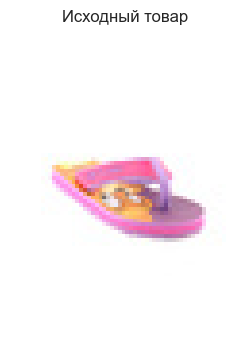


--- Рекомендации от resnet50: ---


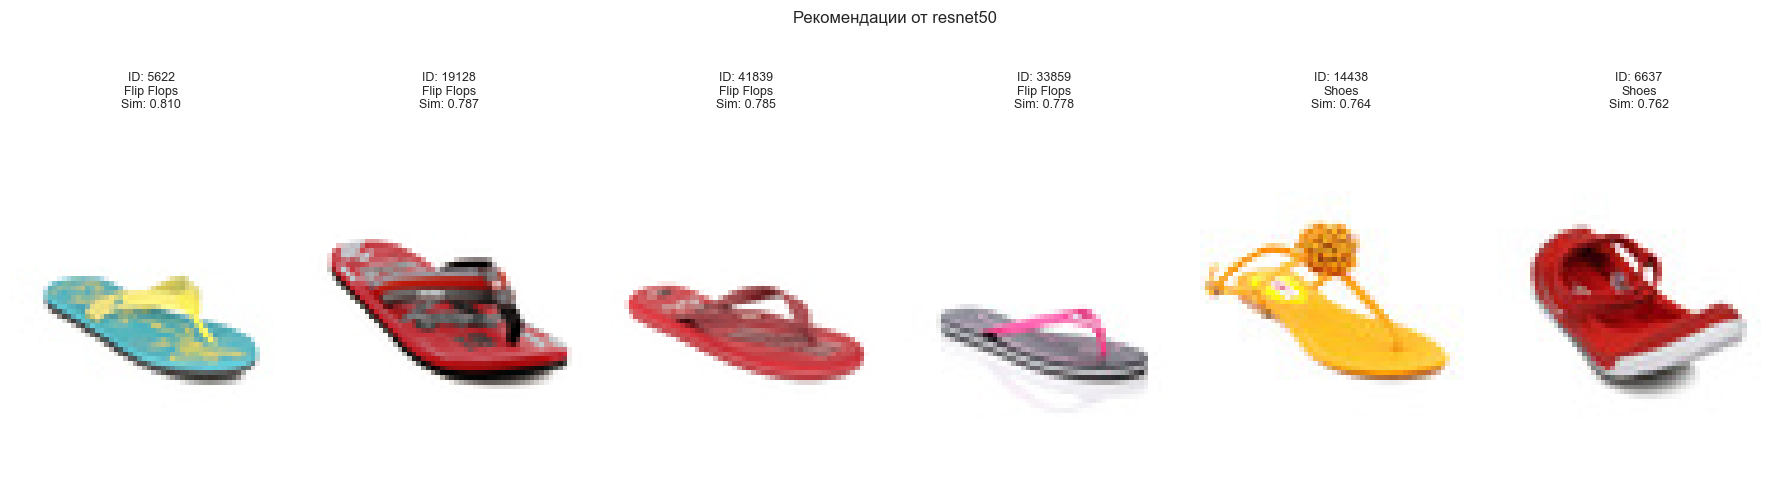


--- Рекомендации от vgg16: ---


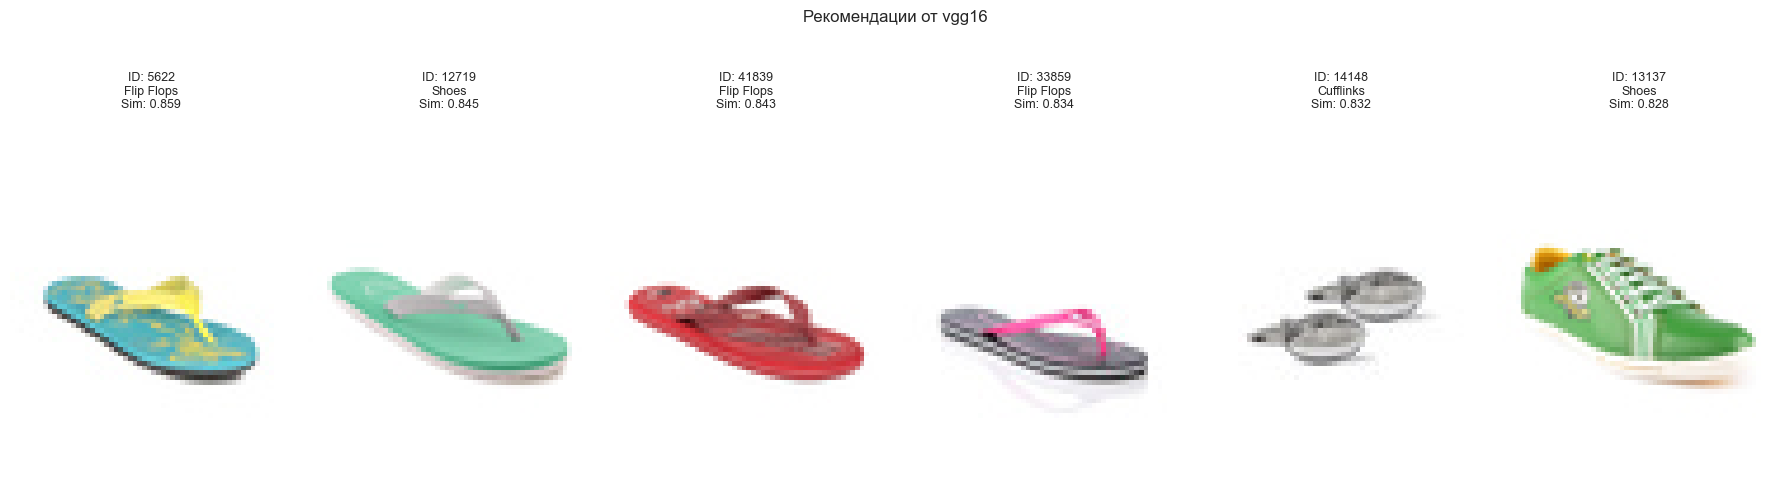


--- Рекомендации от efficientnetb0: ---


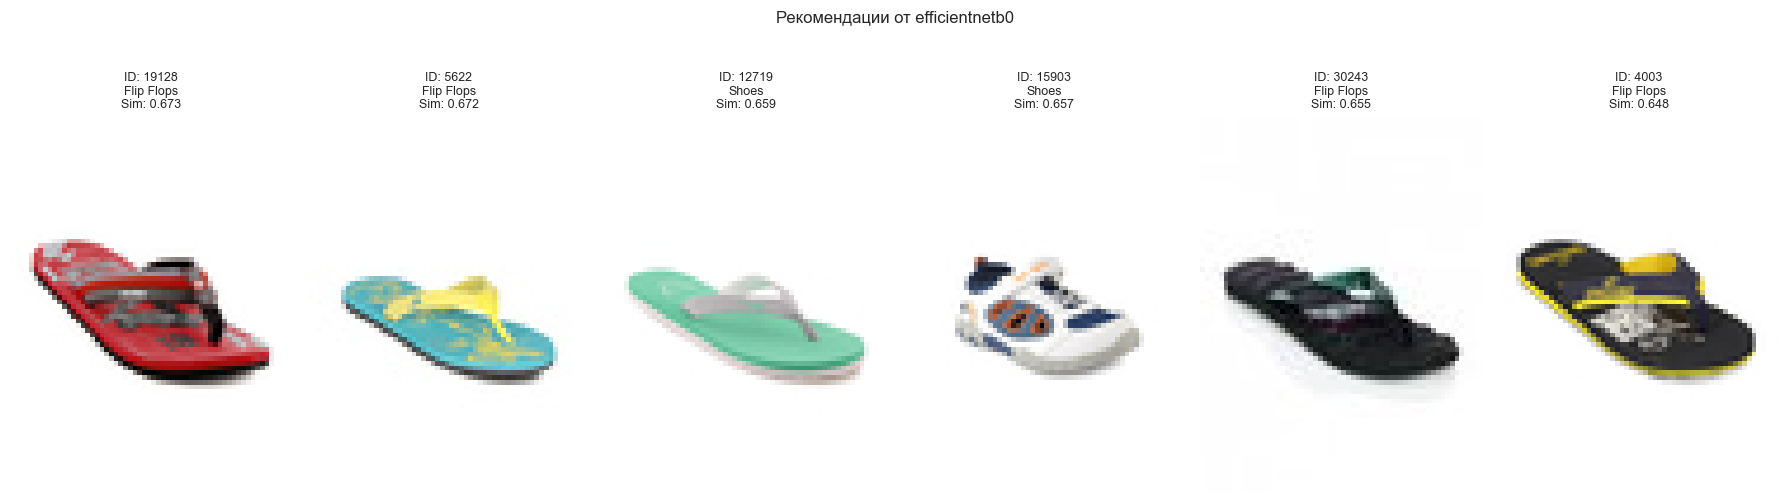


==================== Сравнение для Товара ID: 56072 ====================
Название: Colorbar Wild Berry Lip Liner /Crayon 011
Категория: Personal Care / Lips / Lip Liner
Пол: Women | Сезон: Spring | Использование: Casual


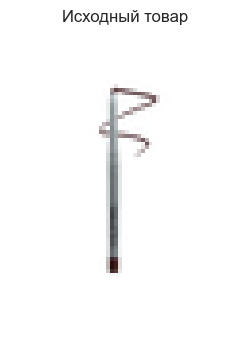


--- Рекомендации от resnet50: ---


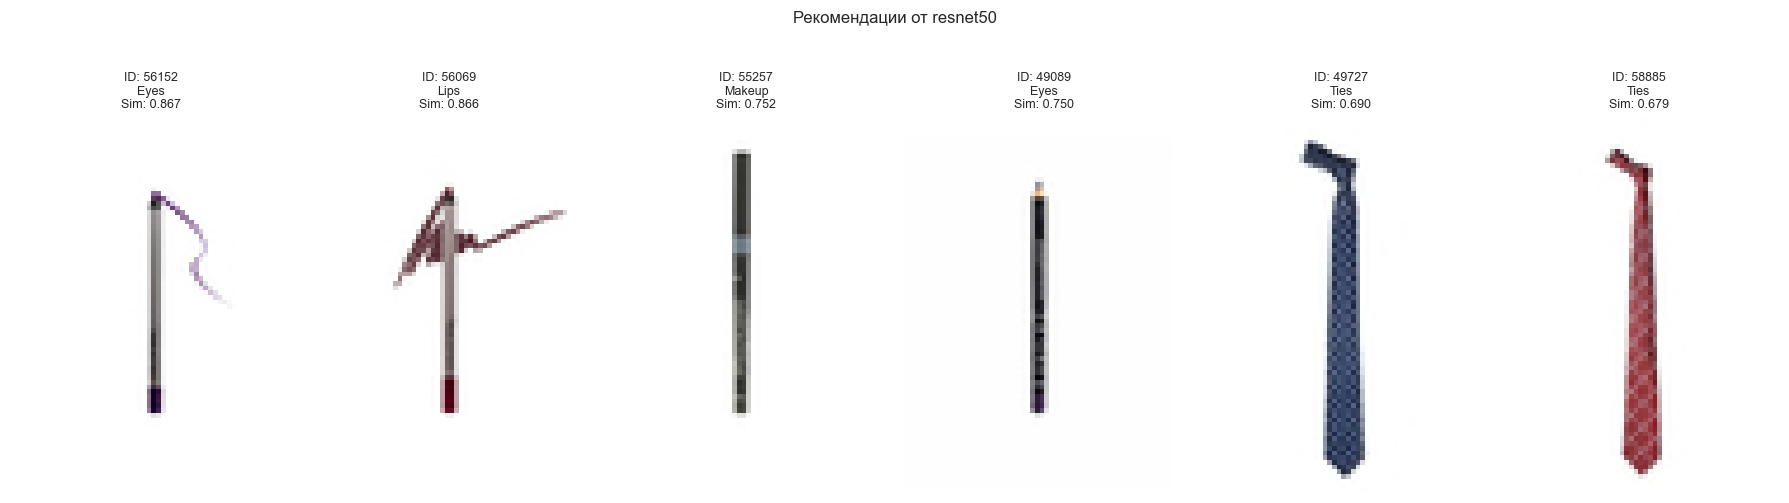


--- Рекомендации от vgg16: ---


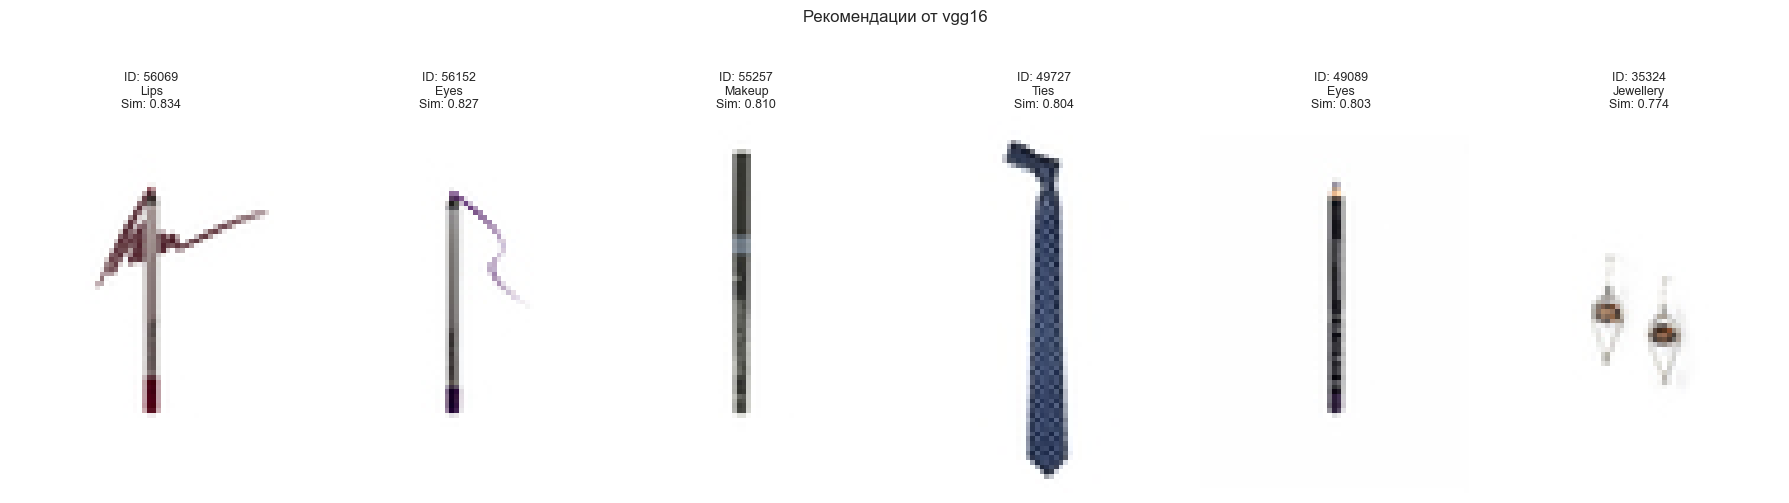


--- Рекомендации от efficientnetb0: ---


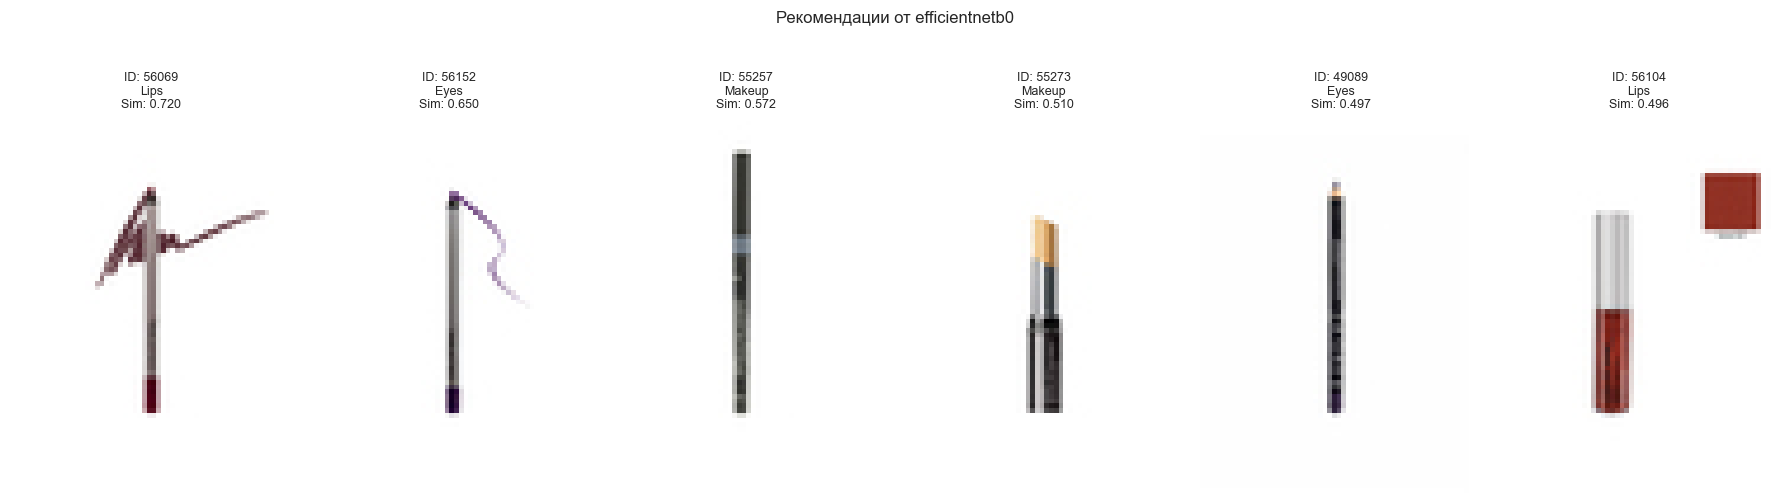


==================== Сравнение для Товара ID: 12297 ====================
Название: Genesis Men Stripes Blue Shirts
Категория: Apparel / Topwear / Shirts
Пол: Men | Сезон: Fall | Использование: Formal


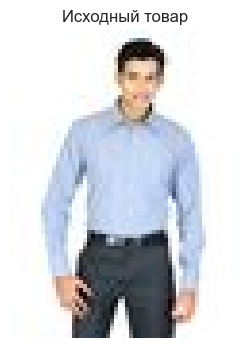


--- Рекомендации от resnet50: ---


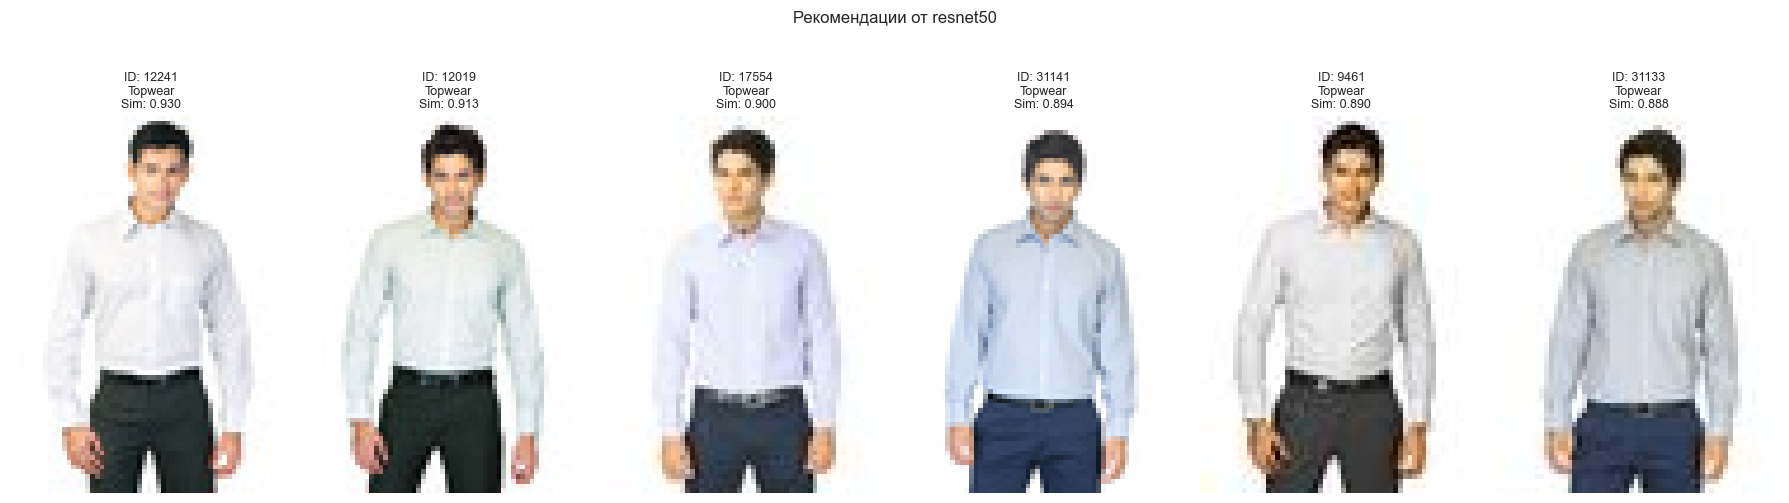


--- Рекомендации от vgg16: ---


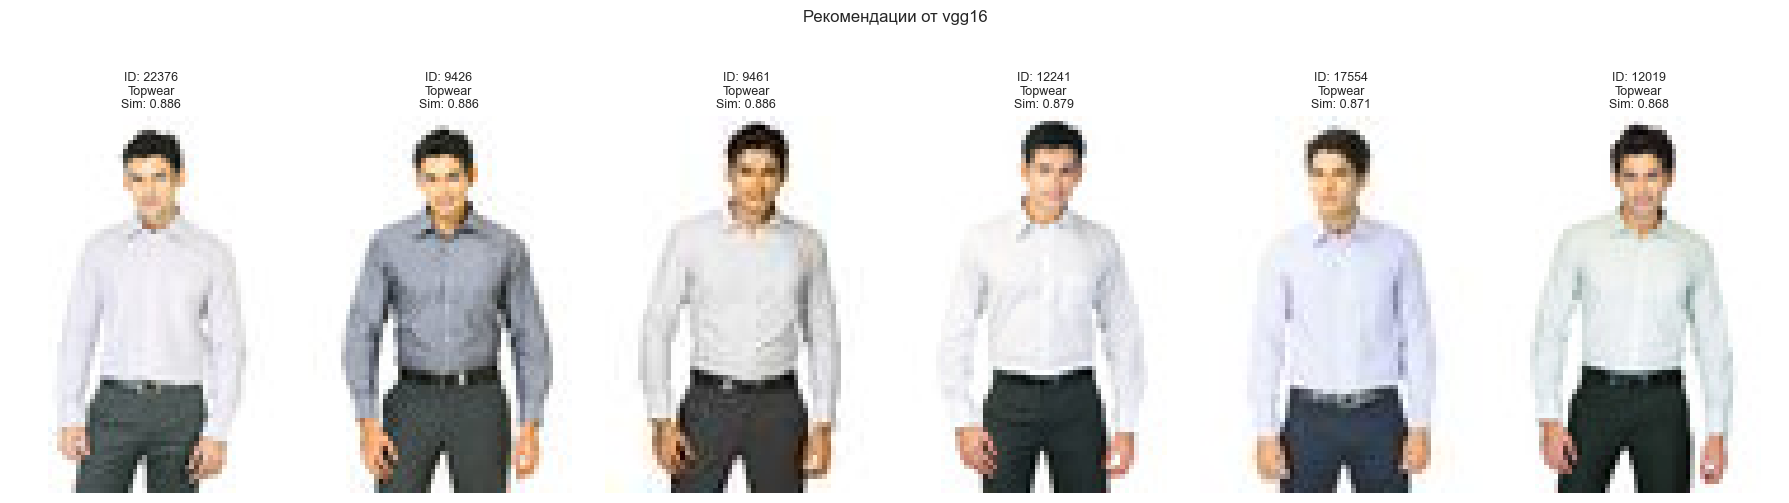


--- Рекомендации от efficientnetb0: ---


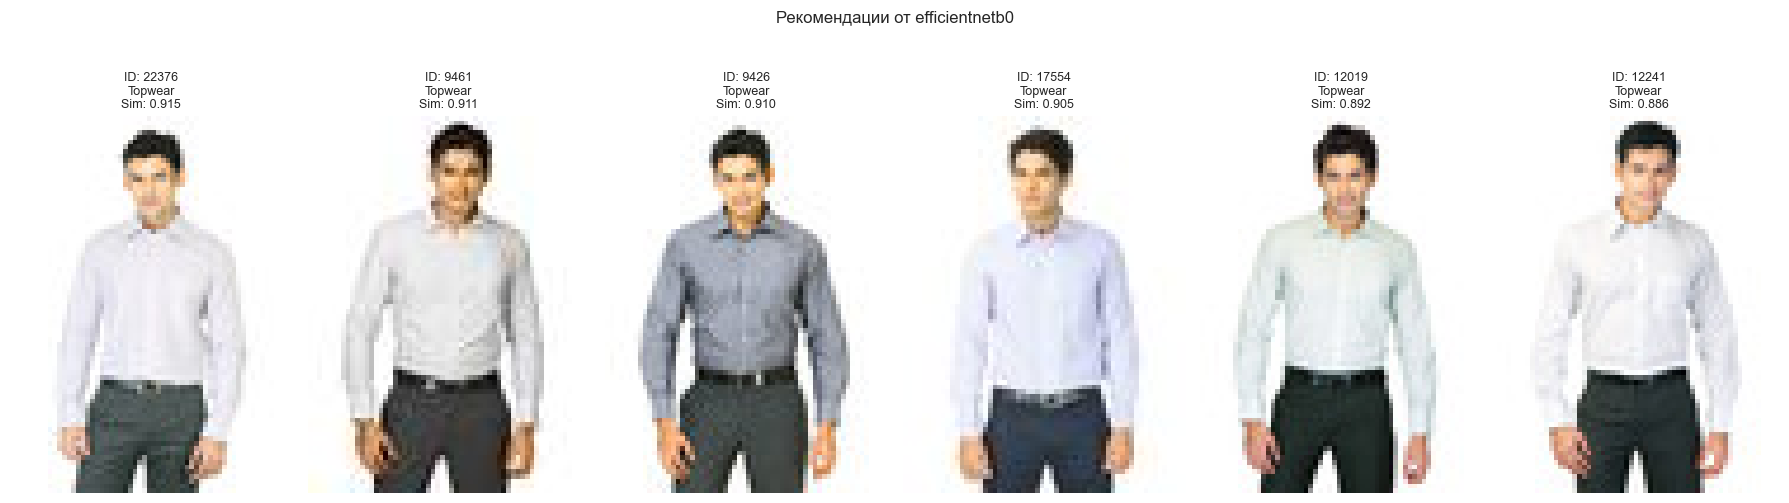


[Evaluation] Количественная оценка моделей (прокси-метрика: совпадение subCategory)...


Оценка resnet50:   0%|                                                      | 0/100 [00:00<?, ?it/s]

resnet50: Средняя доля совпадений subCategory = 0.7617 (оценено 100 товаров)


Оценка vgg16:   0%|                                                         | 0/100 [00:00<?, ?it/s]

vgg16: Средняя доля совпадений subCategory = 0.7533 (оценено 100 товаров)


Оценка efficientnetb0:   0%|                                                | 0/100 [00:00<?, ?it/s]

efficientnetb0: Средняя доля совпадений subCategory = 0.7783 (оценено 100 товаров)

[Evaluation] Модель с лучшей прокси-метрикой: efficientnetb0 (Score: 0.7783)

[Selection] Выбранная лучшая модель: 'efficientnetb0'

[Saving] Сохранение результатов для модели 'efficientnetb0'...
- Матрица фичей сохранена: best_model_features.npy (форма: (450, 1280))
- Список ID товаров сохранен: product_ids.npy (количество: 450)
- Обработанные метаданные сохранены: processed_metadata.pkl (форма: (450, 11))

[Saving] Все результаты успешно сохранены.

--- Выполнение скрипта завершено ---


In [9]:
# ============================================
# ШАГ 4: Выбор лучшей модели и сохранение
# ============================================
print("\n--- Шаг 4: Выбор лучшей модели и сохранение ---")

if final_feature_matrices and not df_final_metadata.empty: # Продолжаем, если есть фичи и метаданные

    # 1. Функция для получения рекомендаций
    def get_recommendations(product_id, features_matrix, product_ids_list, metadata_df, top_n=TOP_N_RECOMMENDATIONS):
        """Находит top_n похожих товаров для заданного product_id."""
        try:
            product_idx = product_ids_list.index(product_id)
            product_features = features_matrix[product_idx].reshape(1, -1)
            similarities = cosine_similarity(product_features, features_matrix)[0]
            # Сортируем индексы по убыванию схожести
            most_similar_indices = np.argsort(similarities)[::-1]
            # Исключаем сам товар (он всегда будет первым с score=1.0)
            recommended_indices = [idx for idx in most_similar_indices if idx != product_idx][:top_n]
            recommended_product_ids = [product_ids_list[idx] for idx in recommended_indices]
            # Возвращаем DataFrame с рекомендованными товарами и их схожестью
            recs_df = metadata_df.iloc[recommended_indices].copy()
            recs_df['similarity'] = similarities[recommended_indices]
            return recs_df

        except ValueError:
            print(f"Предупреждение: Товар с ID {product_id} не найден в списке обработанных товаров.")
            return pd.DataFrame()
        except Exception as e:
            print(f"Ошибка при получении рекомендаций для ID {product_id}: {e}")
            return pd.DataFrame()

    # 2. Качественная оценка моделей (визуальное сравнение)
    print("\n[Evaluation] Качественная оценка моделей (визуальное сравнение)...")
    def display_recommendations_comparison(product_id, models_features, product_ids, metadata_df, top_n=TOP_N_RECOMMENDATIONS):
        """Отображает товар и рекомендации от разных моделей."""
        try:
            source_product = metadata_df[metadata_df['id'] == product_id].iloc[0]
        except IndexError:
            print(f"ОШИБКА: Не удалось найти исходный товар с ID {product_id} в df_final_metadata.")
            return

        print(f"\n{'='*20} Сравнение для Товара ID: {product_id} {'='*20}")
        print(f"Название: {source_product.get('productDisplayName', 'N/A')}")
        print(f"Категория: {source_product.get('masterCategory', 'N/A')} / {source_product.get('subCategory', 'N/A')} / {source_product.get('articleType', 'N/A')}")
        print(f"Пол: {source_product.get('gender', 'N/A')} | Сезон: {source_product.get('season', 'N/A')} | Использование: {source_product.get('usage', 'N/A')}")

        plt.figure(figsize=(4, 4))
        try:
            img = Image.open(source_product['image_path'])
            plt.imshow(img)
            plt.title("Исходный товар")
            plt.axis('off')
            plt.show()
        except Exception as e:
            print(f"Не удалось загрузить изображение исходного товара: {e}")

        for model_name, features in models_features.items():
            if features is None: continue # Пропускаем, если для этой модели нет фичей

            print(f"\n--- Рекомендации от {model_name}: ---")
            recommendations_df = get_recommendations(product_id, features, product_ids, metadata_df, top_n)

            if recommendations_df.empty:
                print("Не удалось получить рекомендации.")
                continue

            plt.figure(figsize=(top_n * 3, 5)) # Увеличил высоту
            for i, (idx, row) in enumerate(recommendations_df.iterrows()):
                plt.subplot(1, top_n, i + 1)
                try:
                    img = Image.open(row['image_path'])
                    plt.imshow(img)
                    sim_score = row['similarity']
                    title = (f"ID: {row['id']}\n{row['subCategory']}\nSim: {sim_score:.3f}")
                    plt.title(title, fontsize=9)
                    plt.axis('off')
                except Exception as e:
                    plt.title(f"ID: {row['id']}\nError: {e}", fontsize=8, color='red')
                    plt.axis('off')
            plt.suptitle(f"Рекомендации от {model_name}", y=1.05) # Сдвинул заголовок выше
            plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Отрегулировал layout
            plt.show()

    # Выбираем несколько случайных ID для визуальной оценки
    if len(final_product_ids) >= N_QUALITATIVE_SAMPLES:
        test_ids = np.random.choice(final_product_ids, N_QUALITATIVE_SAMPLES, replace=False).tolist()
        for test_id in test_ids:
            display_recommendations_comparison(test_id, final_feature_matrices, final_product_ids, df_final_metadata)
    else:
        print("[Evaluation] Недостаточно товаров для проведения качественной оценки.")

    # 3. (Опционально) Количественная оценка (прокси-метрика: совпадение подкатегории)
    print("\n[Evaluation] Количественная оценка моделей (прокси-метрика: совпадение subCategory)...")
    def evaluate_model_proxy(model_name, features_matrix, product_ids, metadata_df, top_n=TOP_N_RECOMMENDATIONS, sample_size=N_QUANTITATIVE_SAMPLES):
        if features_matrix is None: return 0.0, 0 # Возвращаем 0, если нет фичей
        total_score = 0
        count = 0

        if len(product_ids) == 0: return 0.0, 0
        eval_ids = np.random.choice(product_ids, min(sample_size, len(product_ids)), replace=False).tolist()
        
        id_to_subcategory = metadata_df.set_index('id')['subCategory'].to_dict()

        for product_id in tqdm(eval_ids, desc=f"Оценка {model_name}", leave=False, ncols=100):
            source_subcategory = id_to_subcategory.get(product_id)
            if source_subcategory is None: continue # Пропускаем, если ID нет в маппинге (не должно быть)

            recs_df = get_recommendations(product_id, features_matrix, product_ids, metadata_df, top_n)
            if not recs_df.empty:
                match_count = recs_df[recs_df['subCategory'] == source_subcategory].shape[0]
                total_score += match_count / top_n # Доля совпадений в топ-N
                count += 1

        return (total_score / count) if count > 0 else 0.0, count

    scores = {}
    eval_counts = {}
    for model_name, features in final_feature_matrices.items():
        if features is not None:
            score, n_evaluated = evaluate_model_proxy(model_name, features, final_product_ids, df_final_metadata)
            scores[model_name] = score
            eval_counts[model_name] = n_evaluated
            print(f"{model_name}: Средняя доля совпадений subCategory = {score:.4f} (оценено {n_evaluated} товаров)")
        else:
             scores[model_name] = 0.0
             eval_counts[model_name] = 0
             print(f"{model_name}: N/A (нет фичей)")

    # Определение лучшей модели по метрике (если она считалась)
    best_model_name_metric = None
    if scores and any(s > 0 for s in scores.values()): # Если есть ненулевые скоры
         best_model_name_metric = max(scores, key=scores.get)
         print(f"\n[Evaluation] Модель с лучшей прокси-метрикой: {best_model_name_metric} (Score: {scores[best_model_name_metric]:.4f})")
    else:
         print("\n[Evaluation] Не удалось определить лучшую модель по прокси-метрике.")

    # 4. ВЫБОР ЛУЧШЕЙ МОДЕЛИ (!!! РУЧНОЙ ВВОД !!!)
    # Проанализируй визуальные результаты и прокси-метрику (если есть)
    # и впиши имя лучшей модели сюда:
    best_model_name = 'efficientnetb0'  # <--- ЗАМЕНИ НА СВОЙ ВЫБОР ('resnet50', 'vgg16', 'efficientnetb0')
    print(f"\n[Selection] Выбранная лучшая модель: '{best_model_name}'")

    # Проверка, что выбранная модель существует в результатах
    if best_model_name not in final_feature_matrices or final_feature_matrices[best_model_name] is None:
        print(f"ОШИБКА: Выбранная модель '{best_model_name}' отсутствует или для нее нет фичей. Сохранение отменено.")
    else:
        # 5. Сохранение результатов лучшей модели
        print(f"\n[Saving] Сохранение результатов для модели '{best_model_name}'...")
        best_features = final_feature_matrices[best_model_name]

        try:
            # Сохранение матрицы фичей
            np.save(FEATURES_PATH, best_features)
            print(f"- Матрица фичей сохранена: {FEATURES_PATH} (форма: {best_features.shape})")

            # Сохранение списка ID товаров (как numpy array)
            np.save(IDS_PATH, np.array(final_product_ids))
            print(f"- Список ID товаров сохранен: {IDS_PATH} (количество: {len(final_product_ids)})")

            # Сохранение обработанного DataFrame метаданных (используем pickle)
            df_final_metadata.to_pickle(METADATA_PATH_PROCESSED)
            print(f"- Обработанные метаданные сохранены: {METADATA_PATH_PROCESSED} (форма: {df_final_metadata.shape})")

            print("\n[Saving] Все результаты успешно сохранены.")

        except Exception as e:
            print(f"ОШИБКА при сохранении файлов: {e}")

else:
    print("Нет извлеченных фичей или метаданных, выбор и сохранение модели пропущены.")

print("\n--- Выполнение скрипта завершено ---")